In [32]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [33]:
data = pd.read_csv("database.csv")
data.columns

Index(['Date', 'Time', 'Latitude', 'Longitude', 'Type', 'Depth', 'Depth Error',
       'Depth Seismic Stations', 'Magnitude', 'Magnitude Type',
       'Magnitude Error', 'Magnitude Seismic Stations', 'Azimuthal Gap',
       'Horizontal Distance', 'Horizontal Error', 'Root Mean Square', 'ID',
       'Source', 'Location Source', 'Magnitude Source', 'Status'],
      dtype='str')

In [34]:
data = data[['Date', 'Time', 'Latitude', 'Longitude', 'Depth', 'Magnitude']]
data.head()

,Date,Time,Latitude,Longitude,Depth,Magnitude
0,01/02/1965,13:44:18,19.246,145.616,131.6,6.0
1,01/04/1965,11:29:49,1.863,127.352,80.0,5.8
2,01/05/1965,18:05:58,-20.579,-173.972,20.0,6.2
3,01/08/1965,18:49:43,-59.076,-23.557,15.0,5.8
4,01/09/1965,13:32:50,11.938,126.427,15.0,5.8


In [35]:
import datetime
import time

timestamp = []
for d, t in zip(data['Date'], data['Time']):
    try:
        ts = datetime.datetime.strptime(d+' '+t, '%m/%d/%Y %H:%M:%S')
        timestamp.append(time.mktime(ts.timetuple()))
    except ValueError:
        # print('ValueError')
        timestamp.append('ValueError')
timeStamp = pd.Series(timestamp)
data['Timestamp'] = timeStamp.values
final_data = data.drop(['Date', 'Time'], axis=1)
final_data = final_data[final_data.Timestamp != 'ValueError']
final_data.head()

,Latitude,Longitude,Depth,Magnitude,Timestamp
0,19.246,145.616,131.6,6.0,-157650342.0
1,1.863,127.352,80.0,5.8,-157485611.0
2,-20.579,-173.972,20.0,6.2,-157375442.0
3,-59.076,-23.557,15.0,5.8,-157113617.0
4,11.938,126.427,15.0,5.8,-157046230.0


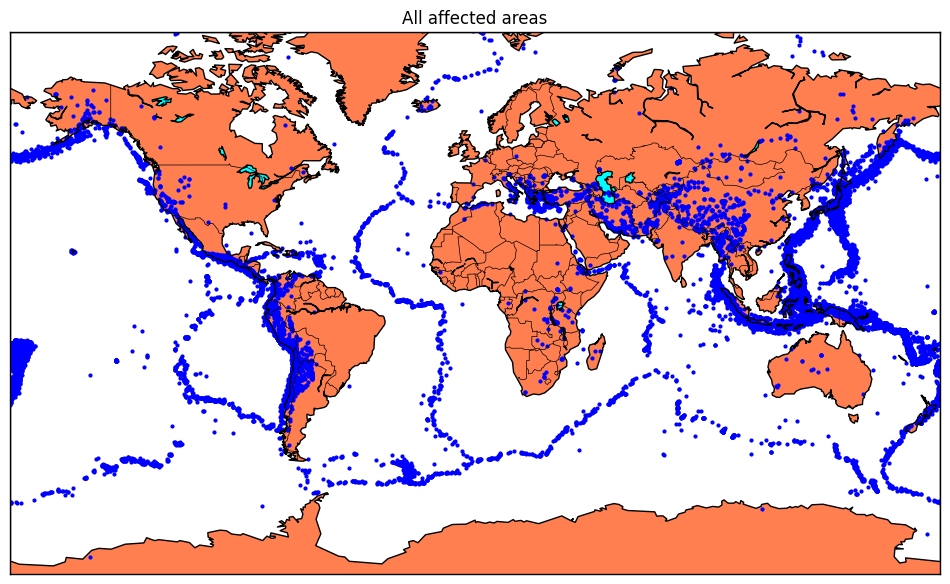

In [36]:
from mpl_toolkits.basemap import Basemap

m = Basemap(projection='mill',llcrnrlat=-80,urcrnrlat=80, llcrnrlon=-180,urcrnrlon=180,lat_ts=20,resolution='c')

longitudes = data["Longitude"].tolist()
latitudes = data["Latitude"].tolist()
#m = Basemap(width=12000000,height=9000000,projection='lcc',
            #resolution=None,lat_1=80.,lat_2=55,lat_0=80,lon_0=-107.)
x,y = m(longitudes,latitudes)

fig = plt.figure(figsize=(12,10))
plt.title("All affected areas")
m.plot(x, y, "o", markersize = 2, color = 'blue')
m.drawcoastlines()
m.fillcontinents(color='coral',lake_color='aqua')
m.drawmapboundary()
m.drawcountries()
plt.show()

In [37]:
X = final_data[['Timestamp', 'Latitude', 'Longitude']]
y = final_data[['Magnitude', 'Depth']]
from sklearn.model_selection import train_test_split, GridSearchCV

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(X_train.shape, X_test.shape, y_train.shape, X_test.shape)

(18727, 3) (4682, 3) (18727, 2) (4682, 3)


In [57]:
from keras.models import Sequential
from keras.layers import Dense

def create_model(**kwargs):
    neurons = kwargs.get('neurons', 16)
    activation = kwargs.get('activation', 'relu')
    optimizer = kwargs.get('optimizer', 'adam')
    loss = kwargs.get('loss', 'mean_squared_error')
    
    model = Sequential()
    model.add(Dense(neurons, activation=activation, input_shape=(3,)))
    model.add(Dense(neurons, activation=activation))
    model.add(Dense(2))
    
    model.compile(optimizer=optimizer, loss=loss, metrics=['mae'])
    
    return model

In [52]:
from scikeras.wrappers import KerasRegressor

model = KerasRegressor(build_fn=create_model, neurons=16, activation='relu', optimizer='adam', loss='mean_squared_error', verbose=0)

# neurons = [16, 64, 128, 256]
neurons = [16]
# batch_size = [10, 20, 50, 100]
batch_size = [10]
epochs = [10]
# activation = ['relu', 'tanh', 'sigmoid', 'hard_sigmoid', 'linear', 'exponential']
activation = ['relu']
# optimizer = ['SGD', 'RMSprop', 'Adagrad', 'Adadelta', 'Adam', 'Adamax', 'Nadam']
# optimizer = ['adam']
# loss = ['mean_squared_error']

param_grid = dict(neurons=neurons, batch_size=batch_size, epochs=epochs, activation=activation)

In [53]:
grid = GridSearchCV(estimator=model, param_grid=param_grid, n_jobs=-1)
grid_result = grid.fit(X_train, y_train)

print("Best: %f using %s" % (grid_result.best_score_, grid_result.best_params_))
means = grid_result.cv_results_['mean_test_score']
stds = grid_result.cv_results_['std_test_score']
params = grid_result.cv_results_['params']
for mean, stdev, param in zip(means, stds, params):
    print("%f (%f) with: %r" % (mean, stdev, param))

/Users/amangiri/Documents/Earthquake-Prediction-NN/venv/lib/python3.13/site-packages/scikeras/wrappers.py:925: UserWarning: ``build_fn`` will be renamed to ``model`` in a future release, at which point use of ``build_fn`` will raise an Error instead.
  X, y = self._initialize(X, y)
/Users/amangiri/Documents/Earthquake-Prediction-NN/venv/lib/python3.13/site-packages/scikeras/wrappers.py:925: UserWarning: ``build_fn`` will be renamed to ``model`` in a future release, at which point use of ``build_fn`` will raise an Error instead.
  X, y = self._initialize(X, y)
/Users/amangiri/Documents/Earthquake-Prediction-NN/venv/lib/python3.13/site-packages/scikeras/wrappers.py:925: UserWarning: ``build_fn`` will be renamed to ``model`` in a future release, at which point use of ``build_fn`` will raise an Error instead.
  X, y = self._initialize(X, y)
/Users/amangiri/Documents/Earthquake-Prediction-NN/venv/lib/python3.13/site-packages/scikeras/wrappers.py:925: UserWarning: ``build_fn`` will be rename

Best: -499625286166.127441 using {'activation': 'relu', 'batch_size': 10, 'epochs': 10, 'neurons': 16}
-499625286166.127441 (996528677801.391846) with: {'activation': 'relu', 'batch_size': 10, 'epochs': 10, 'neurons': 16}


In [58]:
best_model = grid_result.best_estimator_

# Evaluate on test data
test_loss = best_model.score(X_test, y_test)
print("Test Loss (MSE):", test_loss)

# Make predictions
predictions = best_model.predict(X_test)
print("Sample predictions:", predictions[:5])

Test Loss (MSE): -5192031.534040052
Sample predictions: [[-1321.2563    800.6792 ]
 [-1827.2106   1109.017  ]
 [ -287.75473   185.91092]
 [-2081.865    1251.9282 ]
 [-1573.3715    971.739  ]]
